In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [32]:
pip install seaborn


   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 262.6 kB/s eta 0:00:02
   ---- ---------------------------------- 30.7/294.9 kB 262.6 kB/s eta 0:00:02
   ---- ---------------------------------- 30.7/294.9 kB 262.6 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/294.9 kB 151.3 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/294.9 kB 151.3 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/294.9 kB 151.3 kB/s eta 0:00:02
   -------- ------------------------------ 61.4/294.9 kB 156.1 kB/s eta 0:00:02
   --------- ----------------------------- 71.7/294.9 kB 163.8 kB/s eta 0:00:02
   ------------ -------------------------- 92.2/294.9 kB 194.6 kB/s eta 0:0


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "../dataset/train",
    image_size=(128, 128),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "../dataset/test",
    image_size=(128, 128),
    batch_size=32
)

Found 1215 files belonging to 4 classes.
Found 340 files belonging to 4 classes.


In [13]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['alluvial', 'black', 'clay', 'red']


In [14]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    verbose=1   # change to 0 or 1
)

Epoch 1/15
38/38 [==============================] - 11s 273ms/step - loss: 0.0111 - accuracy: 0.9984 - val_loss: 0.0070 - val_accuracy: 0.9971
Epoch 2/15
38/38 [==============================] - 21s 531ms/step - loss: 0.0245 - accuracy: 0.9901 - val_loss: 0.1569 - val_accuracy: 0.9676
Epoch 3/15
38/38 [==============================] - 19s 464ms/step - loss: 0.0273 - accuracy: 0.9934 - val_loss: 0.0135 - val_accuracy: 0.9941
Epoch 4/15
38/38 [==============================] - 18s 434ms/step - loss: 0.0136 - accuracy: 0.9959 - val_loss: 0.0355 - val_accuracy: 0.9941
Epoch 5/15
38/38 [==============================] - 188s 5s/step - loss: 0.0169 - accuracy: 0.9951 - val_loss: 0.0114 - val_accuracy: 0.9941
Epoch 6/15
38/38 [==============================] - 17s 417ms/step - loss: 0.0113 - accuracy: 0.9959 - val_loss: 0.0089 - val_accuracy: 0.9971
Epoch 7/15
38/38 [==============================] - 18s 440ms/step - loss: 0.0160 - accuracy: 0.9959 - val_loss: 0.0089 - val_accuracy: 0.9941
E

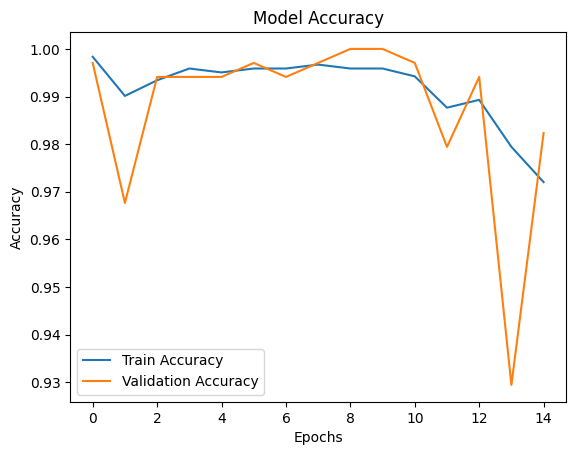

In [26]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

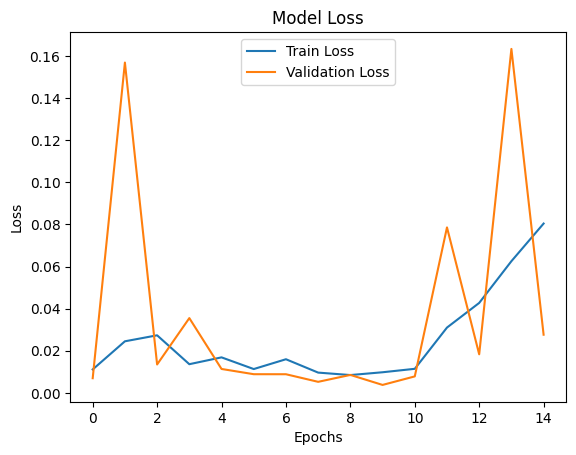

In [27]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 [==============================] - 0s 139ms/step


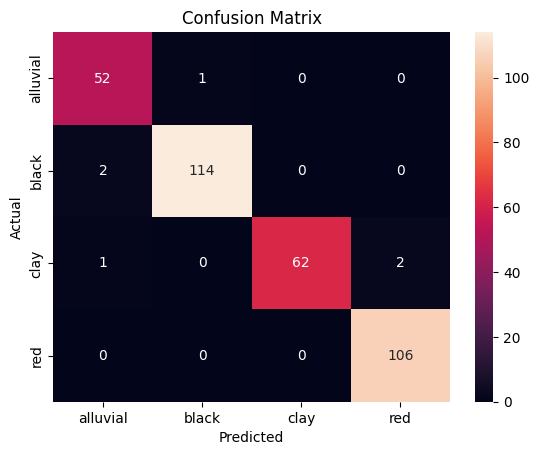

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
model.save("../model/soil_model.h5")
print("Model saved successfully!")

Model saved successfully!


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
